# 交叉验证

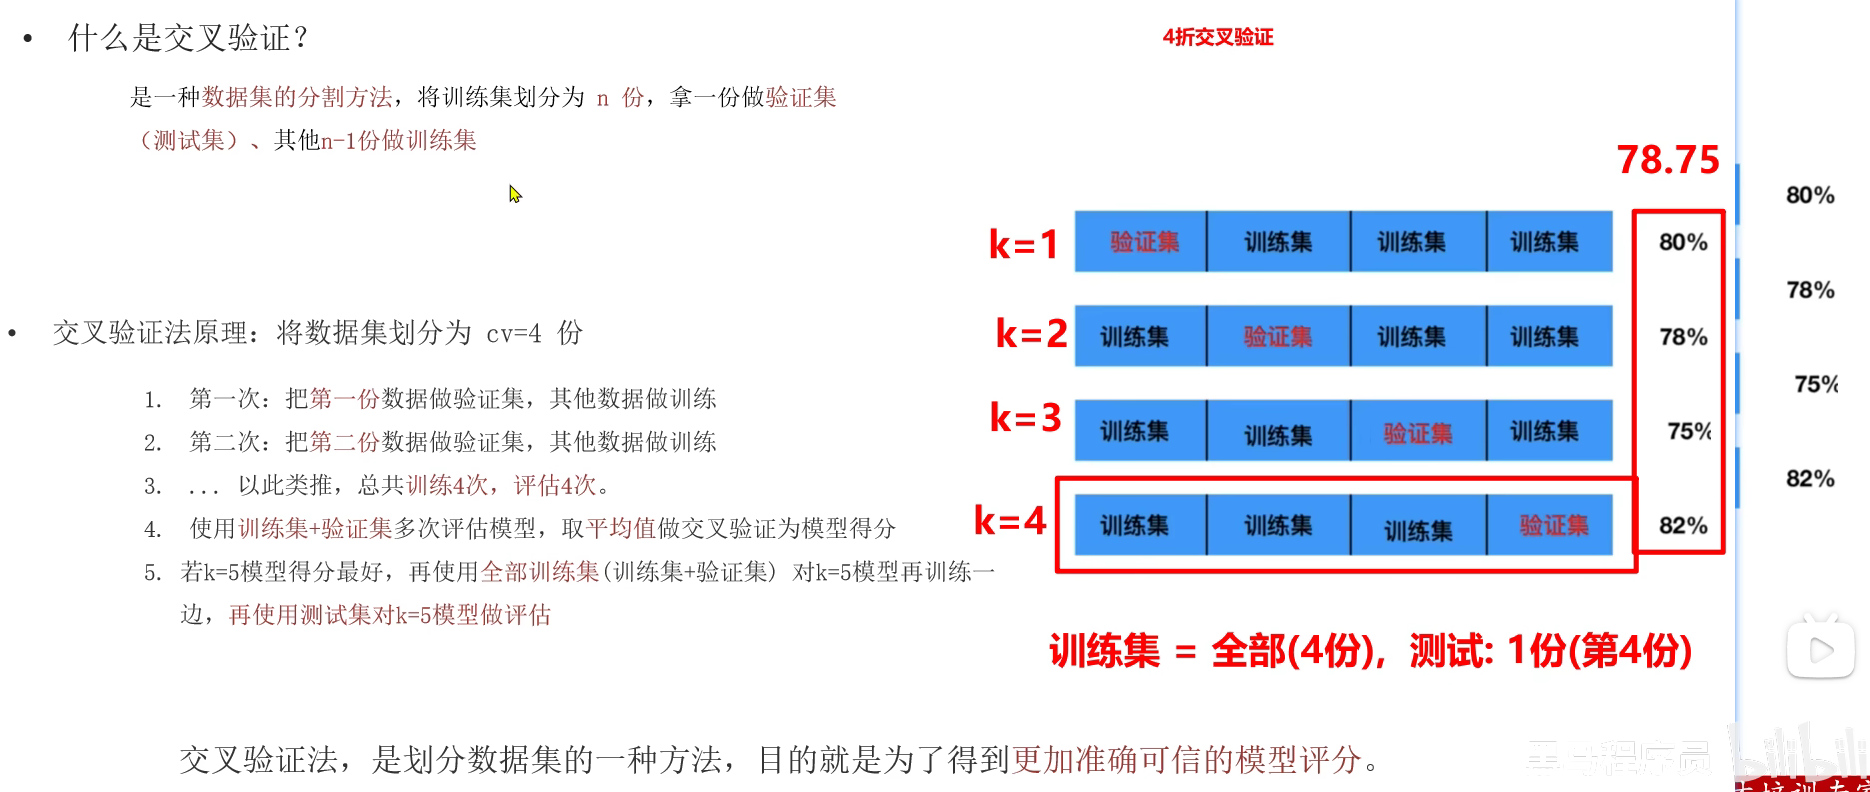

* 分成四分 就是K=4就是4折交叉验证 K=10就是10折交叉验证（别被图像干扰） KNN算法中的K是邻居个数，与这个毫无关系
* 几折就是训练几次 这几次的正确率平均值 作为最终模型训练 参考（重要）
* 假设不算平均分 10 20 30 99 这四次的正确率 你直接选最高的一次的模型训练完之后 模型依旧很笨拙
* 所以不能盲目选择最高一定要参考平均值，如果K=3与K=5均值相同 我们会计算这他们两组数据各个组总正确率的标准差
* 选择一个平均正确率最大的K 在进行一次训练 假如是四折交叉验证 这四份全作为训练集 然后测试集依旧是原来的那一份
* 这里的测试集是训练集的测试集 交叉验证是把训练集分成了很多份 其中有训练集和测试集 真正的测试集是模型定型最后一秒用来打分的，现在可不能泄露
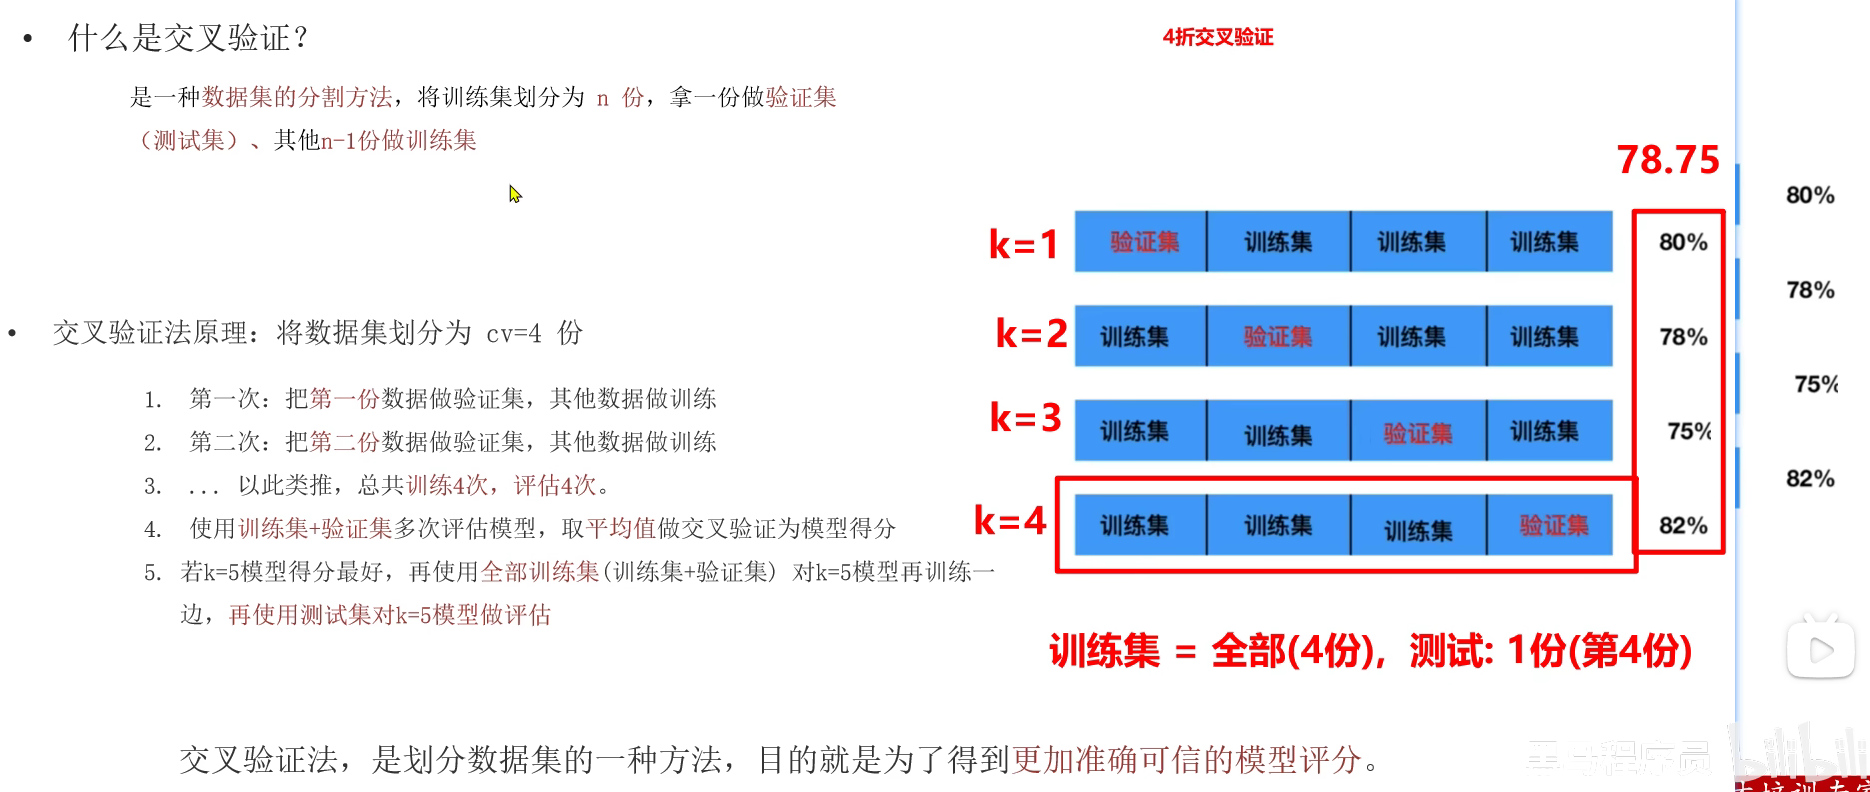

# 网格搜索

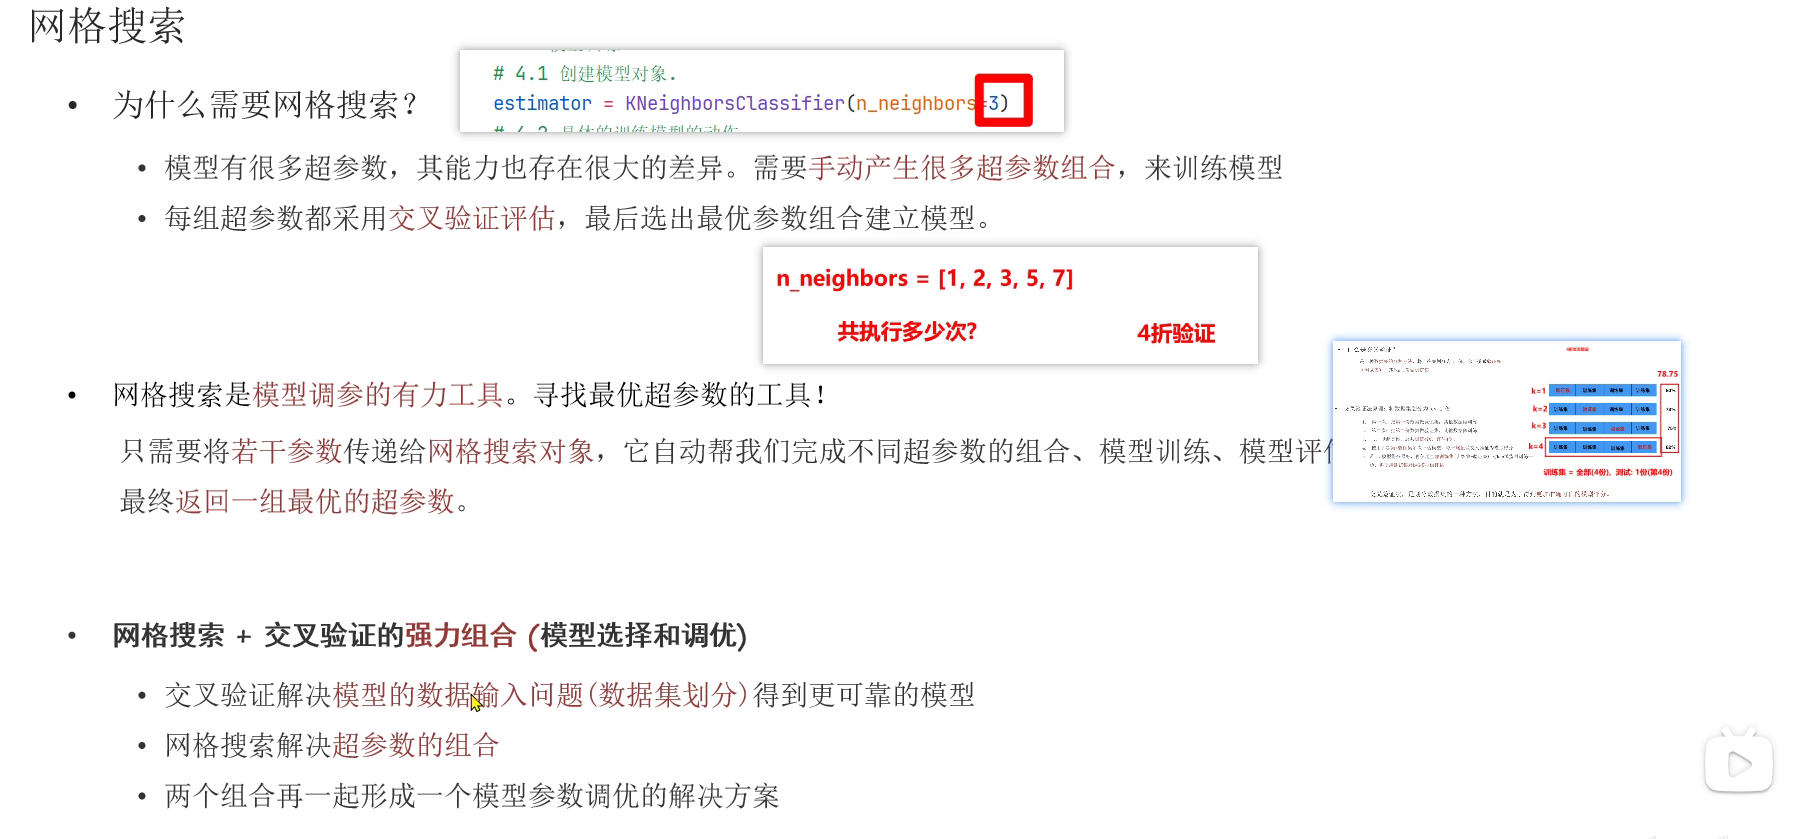

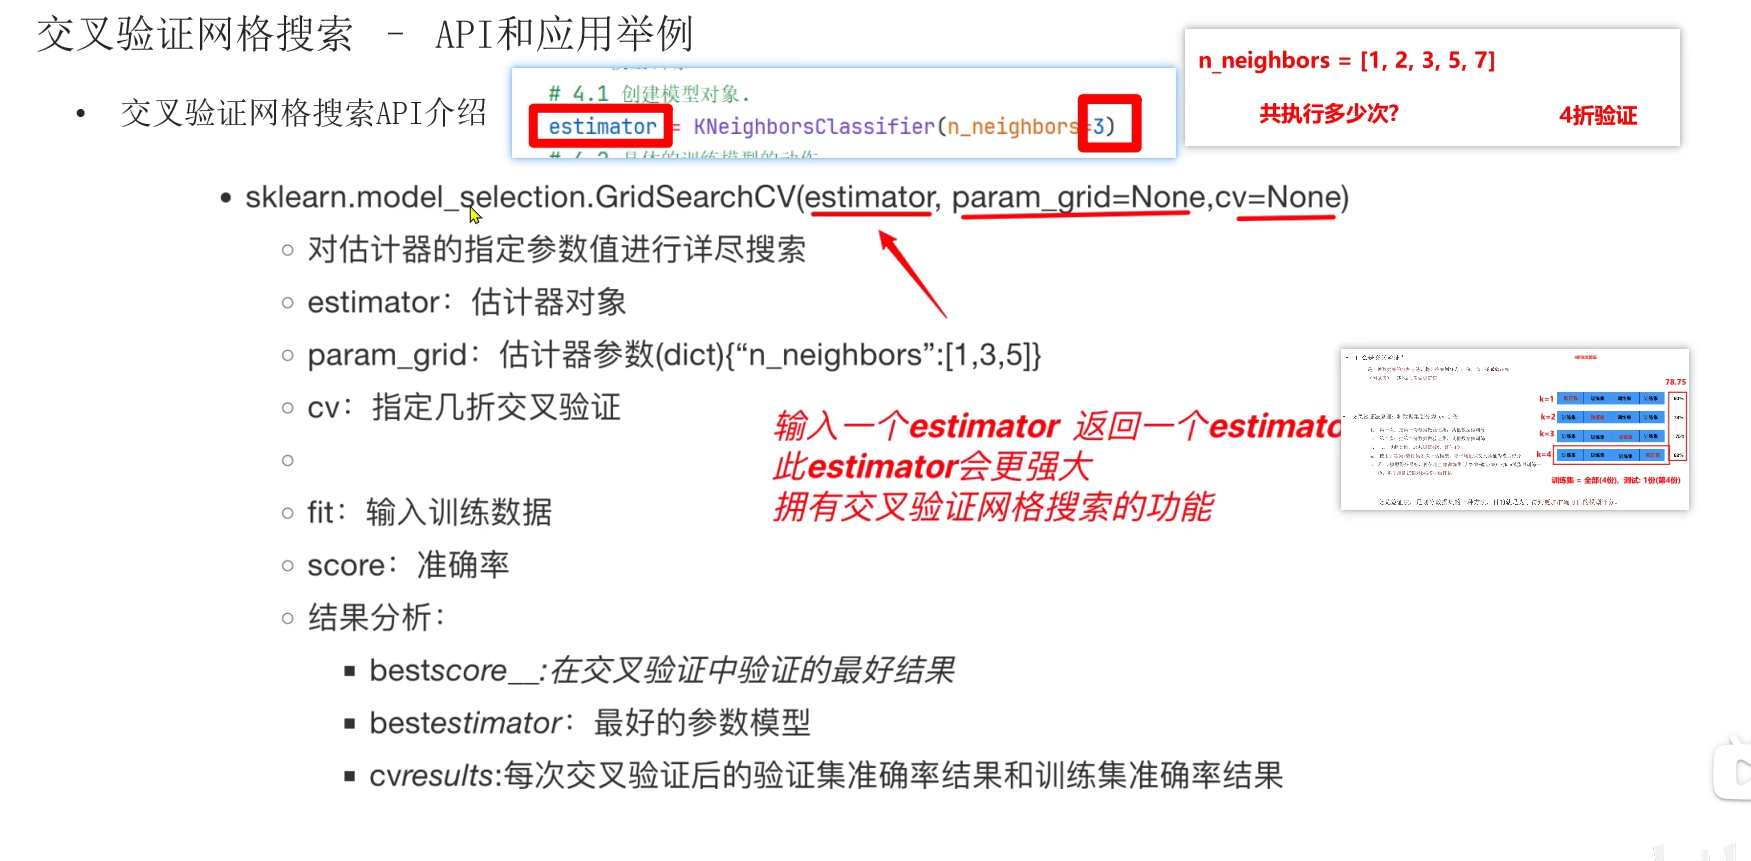

* 如果超参需要多个 会进行排列组合 如果超参只需要一个超参只需遍历即可
* 网格搜索相当于‘力工’，根据交叉验证的方法计算每一个参数
* GridSearchCV这个API就是具体干活的‘人名’

# 具体代码

In [1]:
#导包
from sklearn.datasets import load_iris                  # 加载鸢尾花测试集的.
from sklearn.model_selection import train_test_split,GridSearchCV   # 分割训练集和测试集 寻找最优超参
from sklearn.preprocessing import StandardScaler        # 数据标准化的
from sklearn.neighbors import KNeighborsClassifier      # KNN算法 分类对象
from sklearn.metrics import accuracy_score              # 模型评估的, 计算模型预测的准确率


In [5]:
#1. 加载数据
iris_data=load_iris()

#2. 数据预处理
x_train,x_test,y_train,y_test=train_test_split(iris_data['data'],iris_data['target'],test_size=0.2,random_state=23)

#3. 特征工程 特征预处理——>标准化
#3.1. 创建标准化对象
transform=StandardScaler()
#3.2 对训练集和测试集的特征标准化 测试集集只用transform 不用fit
x_train=transform.fit_transform(x_train)
x_test=transform.transform(x_test)

#4. 模型训练
#4.1 创建KNN分类对象
estimator=KNeighborsClassifier()
#4.2 定义字典 记录可能出现的超参情况（值）
param_dict={'n_neighbors':[i for i in range(1,11)]}
#4.3 创建GridSearchCV对象 寻找最优超参 （网格搜索 交叉验证）
# 参1：要寻炸超参的模型  参2：超参可能出现的值  参3：交叉验证的折数
estimator=GridSearchCV(estimator,param_dict,cv=4) #拥有智能系统的洗衣机
#4.4 模型训练
estimator.fit(x_train,y_train)
#4.5 打印最优超参组合
print(f'最优评分: {estimator.best_score_}')                 # 0.9750000000000001
print(f'最优超参组合: {estimator.best_params_}')             # {'n_neighbors': 8}
print(f'最优的估计器对象: {estimator.best_estimator_}')      # KNeighborsClassifier(n_neighbors=8)
print(f'具体的交叉验证结果: {estimator.cv_results_}')

#5. 模型评估
# 5.1 获取最优的模型对象
estimator=estimator.best_estimator_
# 5.2模型训练
estimator=estimator.fit(x_train,y_train)
#5.3模型预测
y_pred=estimator.predict(x_test)
#5.4 模型评估
print(accuracy_score(y_test,y_pred))



最优评分: 0.9583333333333334
最优超参组合: {'n_neighbors': 7}
最优的估计器对象: KNeighborsClassifier(n_neighbors=7)
具体的交叉验证结果: {'mean_fit_time': array([0.00021225, 0.00024998, 0.00049567, 0.        , 0.00025004,
       0.0002501 , 0.        , 0.00025278, 0.00050008, 0.00049931]), 'std_fit_time': array([0.00036763, 0.00043298, 0.00049571, 0.        , 0.00043308,
       0.00043319, 0.        , 0.00043783, 0.00050008, 0.00049931]), 'mean_score_time': array([0.00014156, 0.00573063, 0.00107604, 0.        , 0.00585091,
       0.00192881, 0.        , 0.0050931 , 0.00199652, 0.00200355]), 'std_score_time': array([2.45190899e-04, 7.04252061e-03, 7.20772989e-04, 0.00000000e+00,
       6.09594469e-03, 1.24023617e-04, 0.00000000e+00, 6.55959804e-03,
       6.88530401e-06, 3.24065142e-06]), 'param_n_neighbors': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value=999999), 'params': [{'n_neighb